
[INFO] Total records loaded: 120
[INFO] Datasets processed: 8
[INFO] Datasets: ['cif_2016', 'etth', 'hospital', 'm3_monthly', 'm4_monthly', 'nn5_weekly', 'tourism_monthly', 'weather']


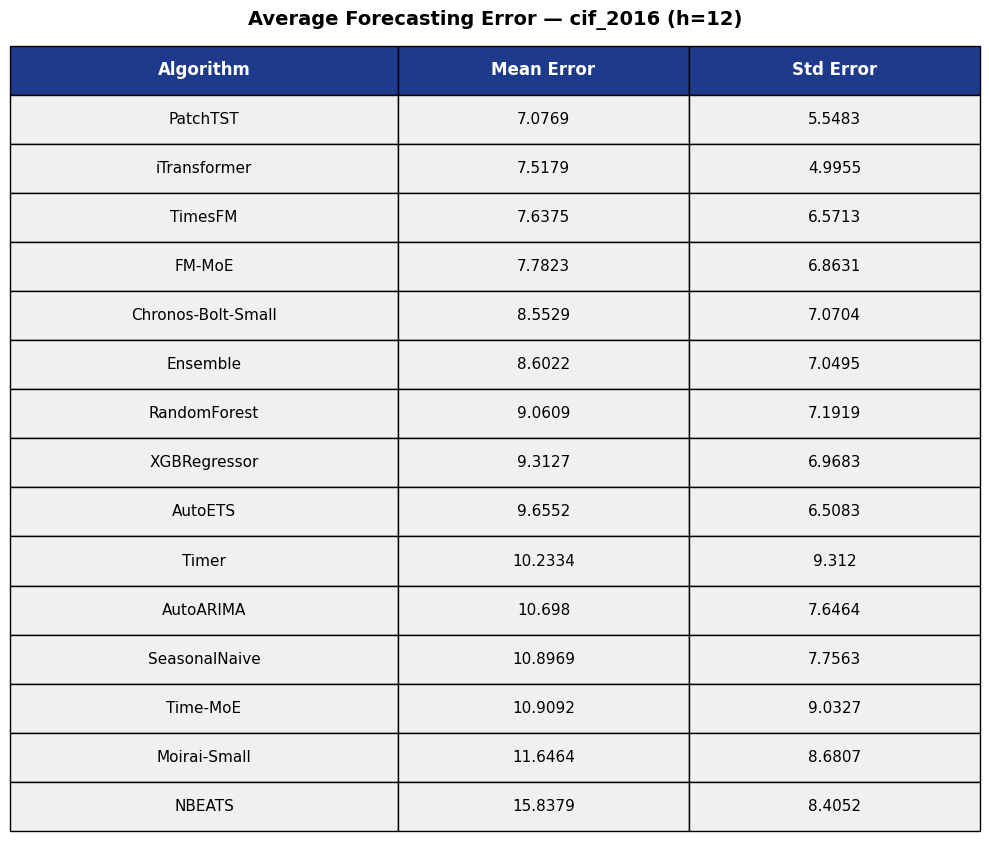

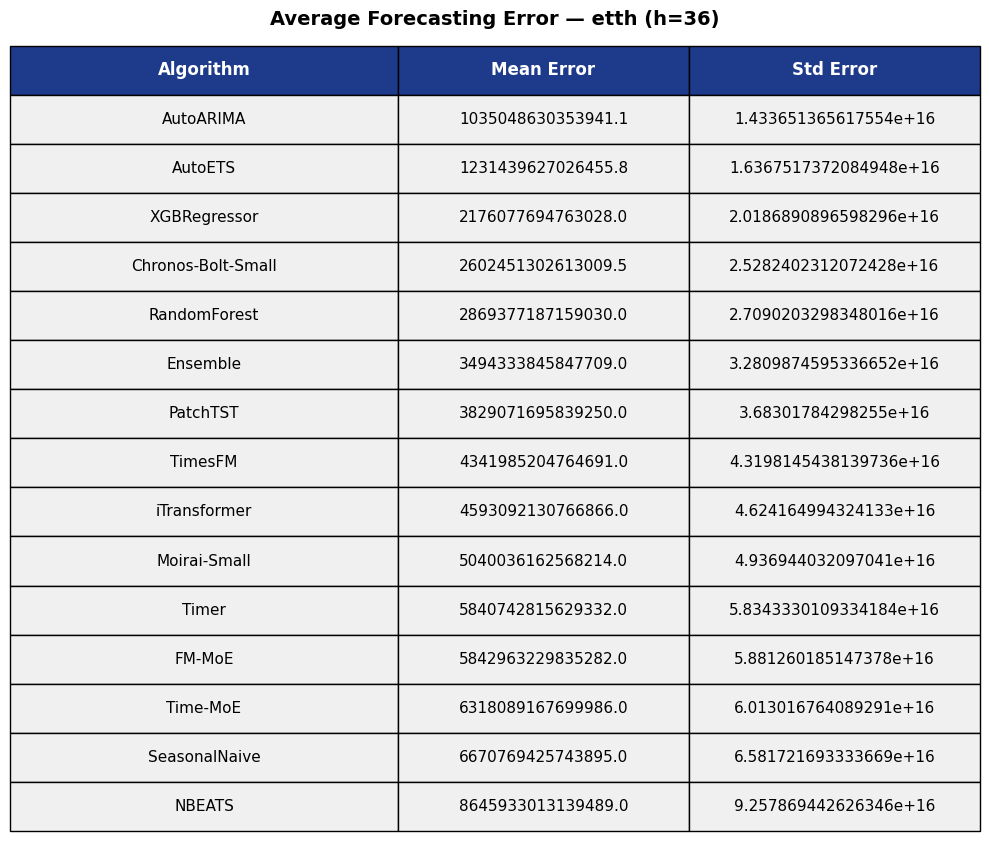

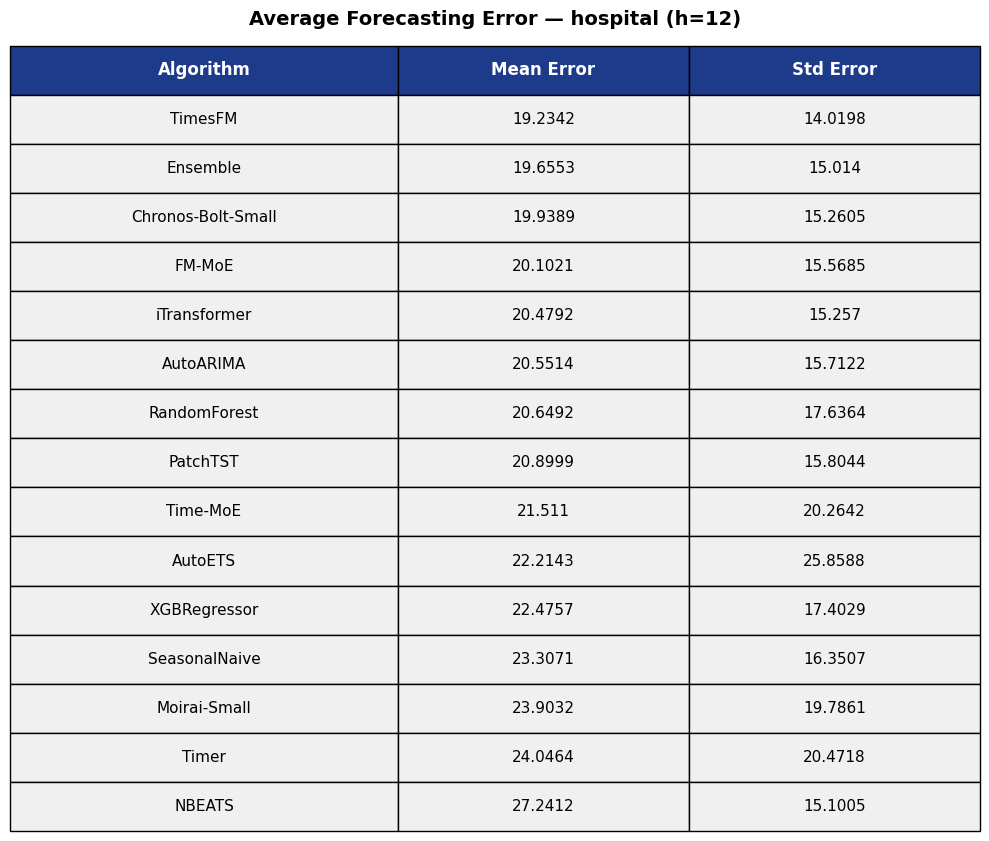

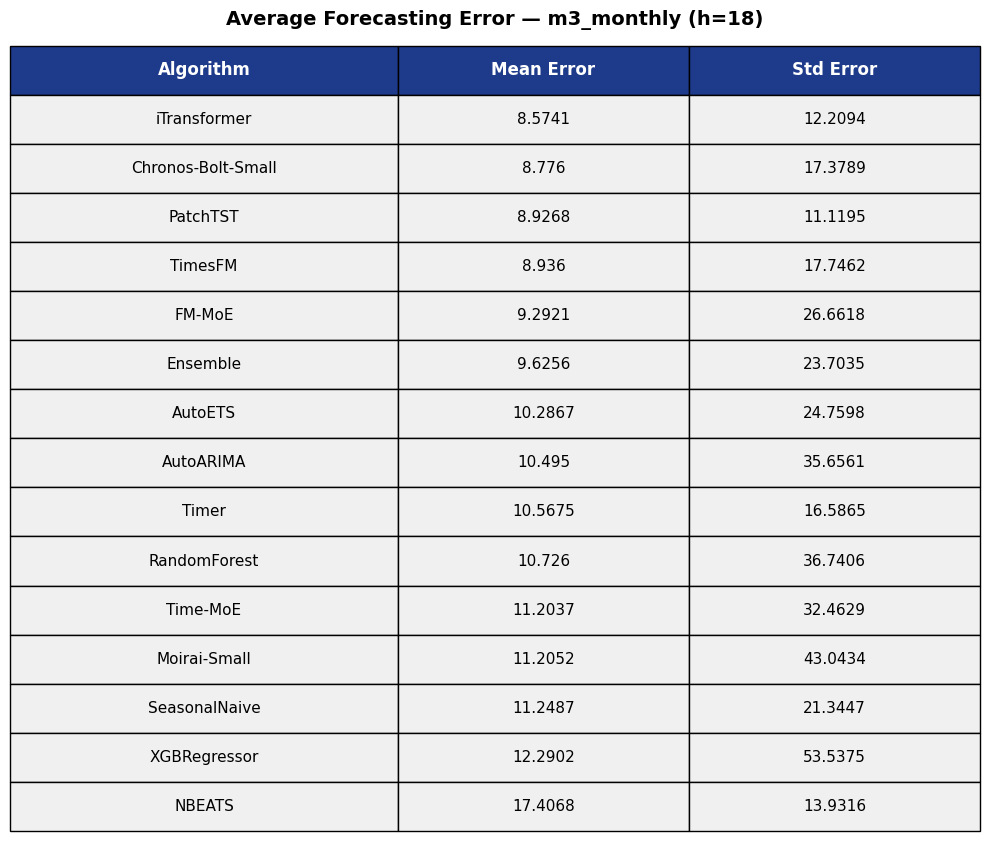

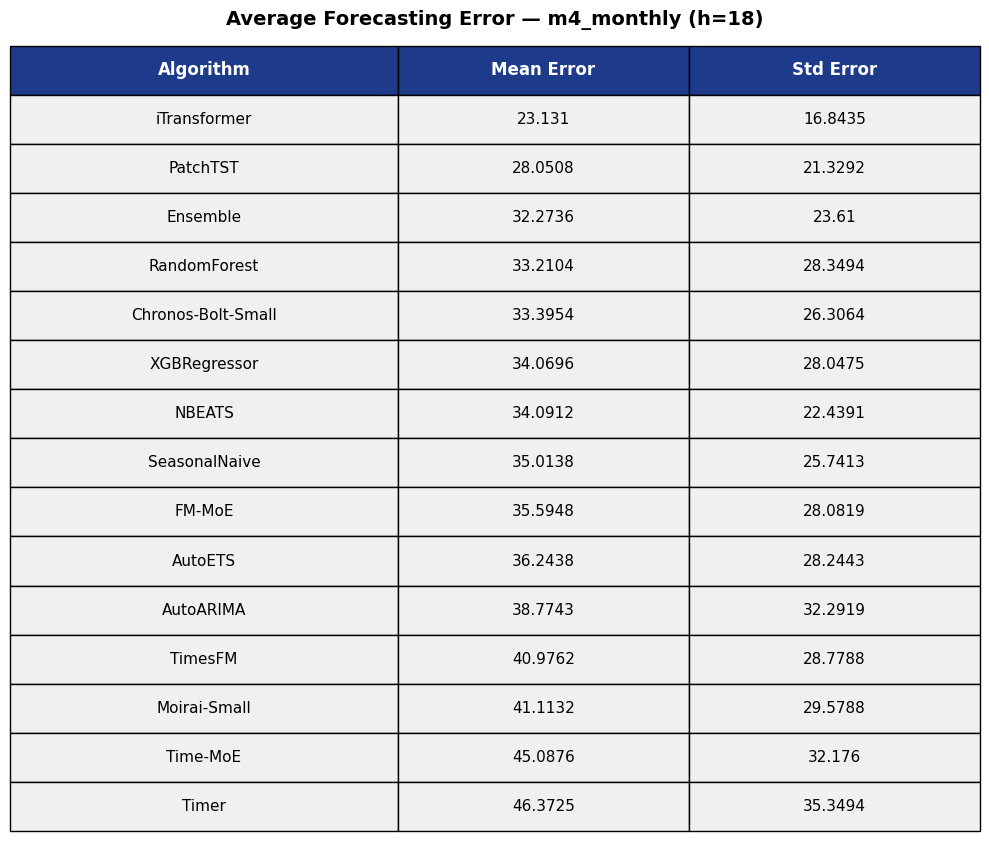

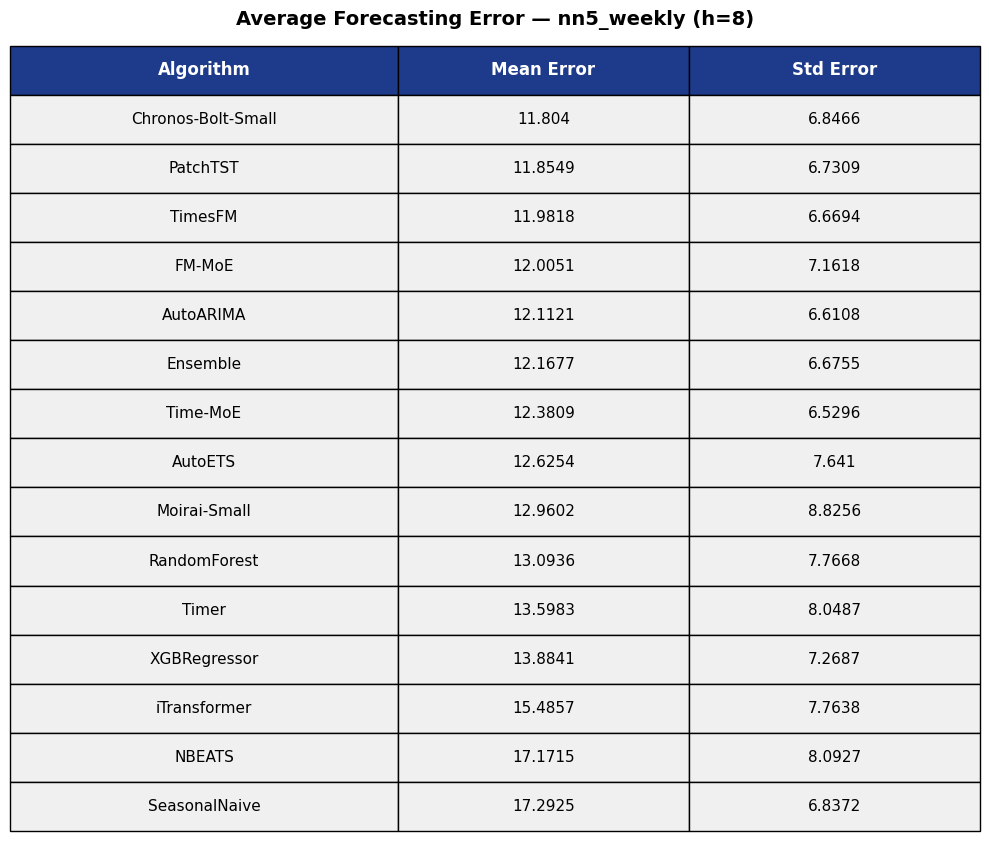

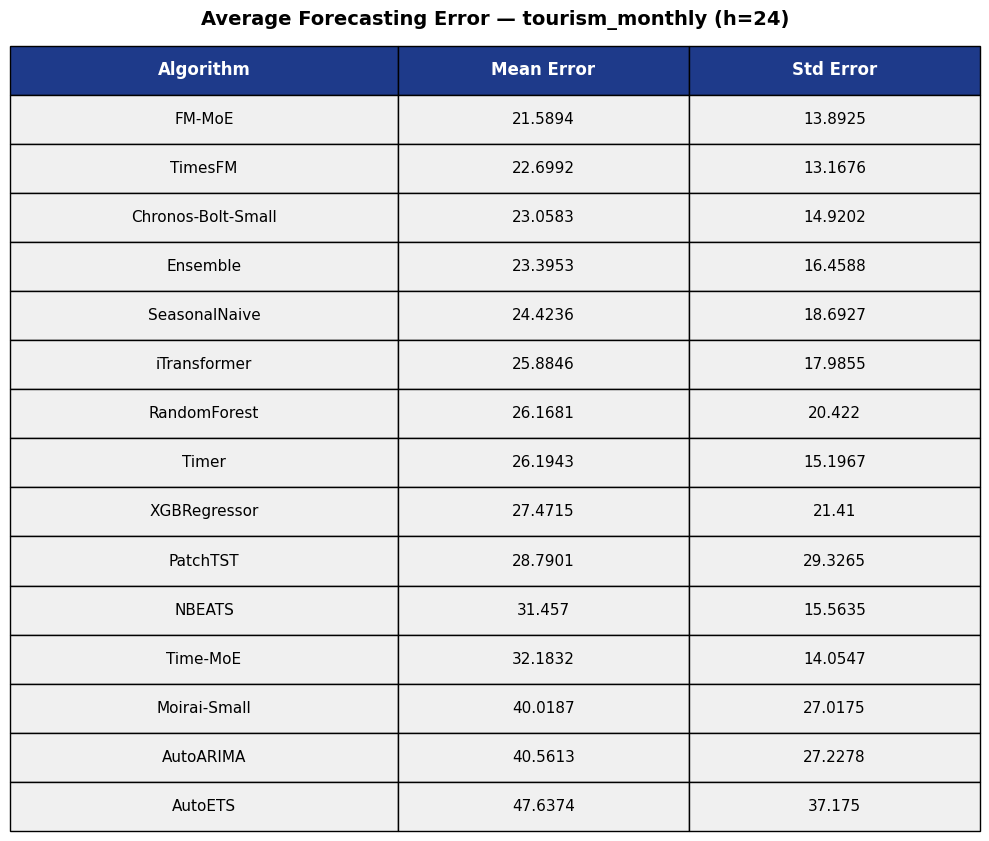

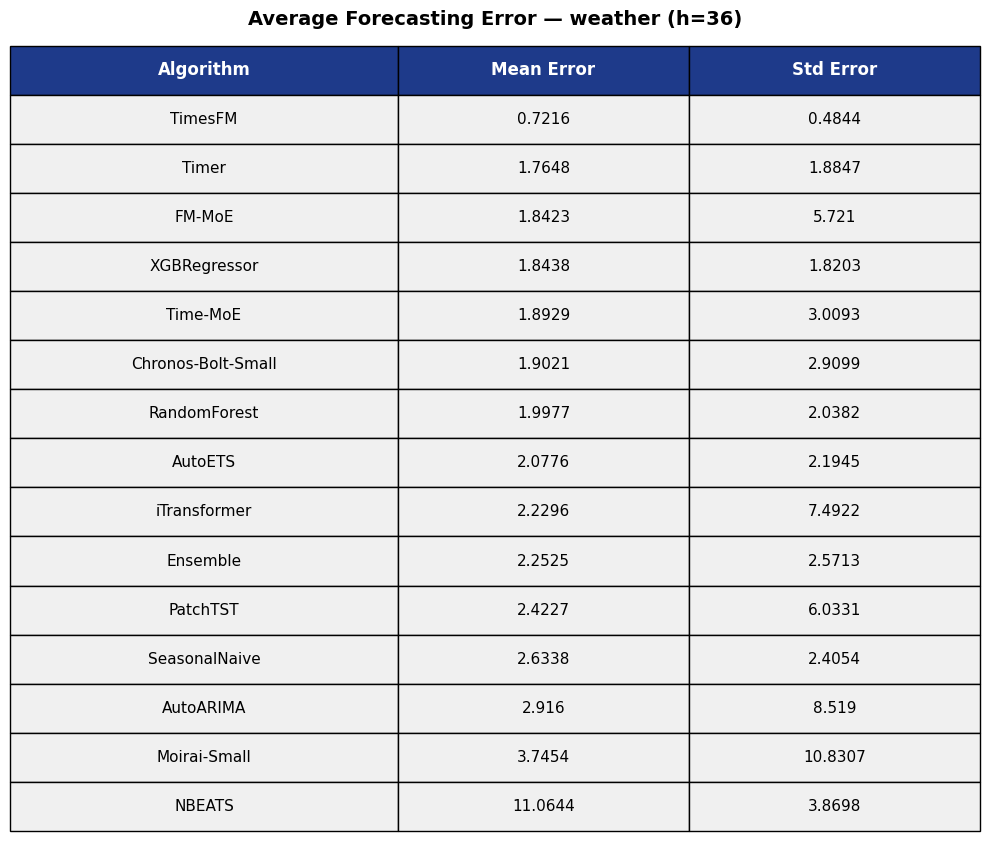


Tables successfully generated.

- Total records: 120
- Unique algorithms: 15
- Datasets: cif_2016, etth, hospital, m3_monthly, m4_monthly, nn5_weekly, tourism_monthly, weather


In [1]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# CONFIGURATION
# ==========================================================
BASE_RESULTS_PATH = "resultados_benchmark_completo/results_benchmark"

DATASETS = {
    "cif_2016_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "etth_filtered":            {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "hospital_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
    "m3_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "m4_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "nn5_weekly_filtered":      {"horizon": 8,  "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
    "tourism_monthly_filtered": {"horizon": 24, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.0001"},
    "weather_filtered":         {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
}

# ==========================================================
# LOAD RESULTS
# ==========================================================
rows_all = []

for dataset_name, info in DATASETS.items():
    config = info["best_config"]
    horizon = info["horizon"]
    file_path = os.path.join(BASE_RESULTS_PATH, config, f"results_{dataset_name}.csv")

    if not os.path.exists(file_path):
        print(f"[WARNING] File not found: {file_path}")
        continue

    df = pd.read_csv(file_path)

    metric_cols = [c for c in df.columns if c != "Modelo" and not c.startswith("Unnamed")]

    for _, row in df.iterrows():
        values = row[metric_cols].values.astype(float)
        rows_all.append({
            "Algorithm": row["Modelo"],
            "Dataset": dataset_name.replace("_filtered", ""),
            "Horizon": horizon,
            "Mean Error": round(np.nanmean(values), 4),
            "Std Error": round(np.nanstd(values), 4),
            "Config": config
        })


# ==========================================================
# BUILD DATAFRAME
# ==========================================================
df_all = pd.DataFrame(rows_all)

if len(df_all) == 0:
    print("\n[ERROR] No data loaded. Check paths.")
else:
    print(f"\n[INFO] Total records loaded: {len(df_all)}")
    print(f"[INFO] Datasets processed: {df_all['Dataset'].nunique()}")
    print(f"[INFO] Datasets: {sorted(df_all['Dataset'].unique())}")

    df_summary = df_all.copy()
    df_summary = df_summary.sort_values(["Dataset", "Mean Error"])

    # ======================================================
    # TABLE VISUALIZATION
    # ======================================================
    datasets = sorted(df_summary["Dataset"].unique())

    for dataset in datasets:
        df_d = df_summary[df_summary["Dataset"] == dataset].copy()
        horizon = df_d["Horizon"].iloc[0]

        df_d["Algorithm"] = df_d["Algorithm"].replace("FM-MoE", "FM-MoE")
        df_d["Algorithm"] = df_d["Algorithm"].replace("Morai", "Moirai")

        df_display = df_d[["Algorithm", "Mean Error", "Std Error"]].copy()

        df_display = df_display.sort_values("Mean Error").reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(10, len(df_display) * 0.5 + 1))
        ax.axis("off")
        ax.axis("tight")

        colors = [["#F0F0F0"] * 3 for _ in df_display["Algorithm"]]

        table = ax.table(
            cellText=df_display.values,
            colLabels=df_display.columns,
            cellLoc="center",
            loc="center",
            colWidths=[0.4, 0.3, 0.3],
            cellColours=colors
        )

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2.5)

        for i in range(len(df_display.columns)):
            cell = table[(0, i)]
            cell.set_facecolor("#1E3A8A")
            cell.set_text_props(weight="bold", color="white", fontsize=12)

        plt.title(
            f"Average Forecasting Error — {dataset} (h={horizon})",
            fontsize=14,
            fontweight="bold",
            pad=20
        )

        plt.tight_layout()
        plt.show()

    print("\nTables successfully generated.")
    print(f"\n- Total records: {len(df_all)}")
    print(f"- Unique algorithms: {df_all['Algorithm'].nunique()}")
    print(f"- Datasets: {', '.join(datasets)}")